# AKAZI SCROLL - salary prediction Model 

# In this notebook, we will perform linear regression and compare four different models basing on LInkedin job postings dataset.

In [216]:
# load dataset

import pandas as pd

# Load the dataset

cols_needed = [
    'job_id', 'title', 'location', 'formatted_work_type',
    'formatted_experience_level', 'remote_allowed',
    'pay_period', 'min_salary', 'max_salary', 'med_salary',
    'normalized_salary', 'currency', 'compensation_type',
    'views', 'applies'
]

df = pd.read_csv("summative/linear_regression/data/postings.csv", usecols=cols_needed)
print("Shape:", df.shape)
df.head()
print(df.dtypes)
print()
print("Null counts:")
print(df.isnull().sum())
print()
print("Duplicate job_id count:", df['job_id'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())



Shape: (123849, 15)
job_id                          int64
title                             str
max_salary                    float64
pay_period                        str
location                          str
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type               str
applies                       float64
remote_allowed                float64
formatted_experience_level        str
currency                          str
compensation_type                 str
normalized_salary             float64
dtype: object

Null counts:
job_id                             0
title                              0
max_salary                     94056
pay_period                     87776
location                           0
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
remote_allow

In [217]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df_salary = df[df['normalized_salary'].notnull()].copy()
print("Rows with salary before filtering:", len(df_salary))
print(df_salary['normalized_salary'].describe())

Rows with salary before filtering: 36073
count        36,073.00
mean        205,327.04
std       5,097,626.76
min               0.00
25%          52,000.00
50%          81,500.00
75%         125,000.00
max     535,600,000.00
Name: normalized_salary, dtype: float64


In [218]:
LOWER_BOUND = 15_000
UPPER_BOUND = 400_000

before = len(df_salary)
df_salary = df_salary[(df_salary['normalized_salary'] >= LOWER_BOUND) & (df_salary['normalized_salary'] <= UPPER_BOUND)].copy()

after = len(df_salary)

print(f"Rows with salary before filtering: {before}")
print(f"Rows with salary after filtering: {after}")
print(f"Rows dropped as outliers: {before - after} ({100*(before-after)/before:.1f}%)")
print()
print(df_salary['normalized_salary'].describe())



Rows with salary before filtering: 36073
Rows with salary after filtering: 35449
Rows dropped as outliers: 624 (1.7%)

count    35,449.00
mean     95,044.30
std      54,194.51
min      15,000.00
25%      52,000.00
50%      82,500.00
75%     124,950.50
max     400,000.00
Name: normalized_salary, dtype: float64


In [219]:
feature_cols = [
    'title', 'location', 'formatted_work_type',
    'formatted_experience_level', 'remote_allowed',
    'views', 'applies'
]

print("Null counts in feature columns (salary-filtered subset):")
print(df_salary[feature_cols].isnull().sum())
print()
print("Unique value counts:")
for col in ['title', 'location', 'formatted_work_type', 'formatted_experience_level']:
    print(f"{col}: {df_salary[col].nunique()} unique values")

Null counts in feature columns (salary-filtered subset):
title                             0
location                          0
formatted_work_type               0
formatted_experience_level     7949
remote_allowed                30699
views                           479
applies                       26799
dtype: int64

Unique value counts:
title: 24104 unique values
location: 4490 unique values
formatted_work_type: 7 unique values
formatted_experience_level: 6 unique values


In [220]:

print("views nulls:", df_salary['views'].isnull().sum())
print("applies nulls:", df_salary['applies'].isnull().sum())
print()

leakage_cols = ['min_salary', 'max_salary', 'med_salary', 'pay_period', 'compensation_type', 'currency']
df_clean = df_salary.drop(columns=leakage_cols + ['remote_allowed'])

df_clean['formatted_experience_level'] = df_clean['formatted_experience_level'].fillna('Not Specified')

df_clean['views'] = df_clean['views'].fillna(0)
df_clean['applies'] = df_clean['applies'].fillna(0)

print("Final shape:", df_clean.shape)
print()
print("Remaining null counts:")
print(df_clean.isnull().sum())
print()
df_clean.head()

views nulls: 479
applies nulls: 26799

Final shape: (35449, 8)

Remaining null counts:
job_id                        0
title                         0
location                      0
views                         0
formatted_work_type           0
applies                       0
formatted_experience_level    0
normalized_salary             0
dtype: int64



,job_id,title,location,views,formatted_work_type,applies,formatted_experience_level,normalized_salary
0,921716,Marketing Coordinator,"Princeton, NJ",20.00,Full-time,2.00,Not Specified,"38,480.00"
1,1829192,Mental Health Therapist/Counselor,"Fort Collins, CO",1.00,Full-time,0.00,Not Specified,"83,200.00"
2,10998357,Assitant Restaurant Manager,"Cincinnati, OH",8.00,Full-time,0.00,Not Specified,"55,000.00"
3,23221523,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",16.00,Full-time,0.00,Not Specified,"157,500.00"
4,35982263,Service Technician,"Burlington, IA",3.00,Full-time,0.00,Not Specified,"70,000.00"


In [221]:
df_clean = df_clean.drop(columns=['applies'])

print("Final shape:", df_clean.shape)
df_clean.dtypes

Final shape: (35449, 7)


job_id                          int64
title                             str
location                          str
views                         float64
formatted_work_type               str
formatted_experience_level        str
normalized_salary             float64
dtype: object

In [222]:
def bucket_title(title):
    t = str(title).lower()
    if any(k in t for k in ['senior', 'sr.', 'sr ', 'lead', 'principal', 'staff']):
        return 'Senior/Lead'
    elif any(k in t for k in ['manager', 'director', 'head of', 'vp', 'chief', 'supervisor', 'superintendent']):
        return 'Management/Executive'
    elif any(k in t for k in ['engineer', 'developer', 'programmer', 'architect']):
        return 'Engineering'
    elif any(k in t for k in ['nurse', 'rn ', ' rn', 'cna', 'therapist', 'clinical', 'medical', 'health',
                               'physician', 'dental', 'phlebotomist', 'pathologist']):
        return 'Healthcare'
    elif any(k in t for k in ['sales', 'account executive', 'business development']):
        return 'Sales'
    elif any(k in t for k in ['marketing', 'seo', 'content', 'social media']):
        return 'Marketing'
    elif any(k in t for k in ['teacher', 'professor', 'instructor', 'tutor']):
        return 'Education'
    elif any(k in t for k in ['analyst', 'data scientist', 'data']):
        return 'Data/Analytics'
    elif any(k in t for k in ['accountant', 'finance', 'financial', 'auditor', 'accounts payable',
                               'accounts receivable', 'bookkeeper', 'payroll', 'controller',
                               'billing', 'accounting']):
        return 'Finance'
    elif any(k in t for k in ['designer', 'design']):
        return 'Design'
    elif any(k in t for k in ['hr ', 'human resources', 'recruiter', 'talent']):
        return 'HR/Recruiting'
    elif any(k in t for k in ['customer service', 'support']):
        return 'Customer Service/Support'
    elif any(k in t for k in ['technician', 'mechanic', 'operator', 'construction',
                               'material handler', 'warehouse', 'package handler']):
        return 'Technical/Trades'
    elif any(k in t for k in ['legal', 'attorney', 'paralegal']):
        return 'Legal'
    elif any(k in t for k in ['administrative', 'assistant', 'receptionist', 'coordinator']):
        return 'Administrative/Office Support'
    elif any(k in t for k in ['cashier', 'cook', 'housekeeper', 'team member', 'merchandiser',
                               'server', 'barista', 'retail']):
        return 'General Labor/Hospitality'
    else:
        return 'Other'

df_clean['title_category'] = df_clean['title'].apply(bucket_title)

print("Category distribution:")
print(df_clean['title_category'].value_counts())
print()
other_pct = (df_clean['title_category'] == 'Other').mean() * 100
print(f"'Other' now: {other_pct:.1f}%")
print(f"Reduced from {df_clean['title'].nunique()} unique titles to {df_clean['title_category'].nunique()} categories")

Category distribution:
title_category
Other                            7088
Management/Executive             6936
Senior/Lead                      5229
Healthcare                       2790
Engineering                      2751
Technical/Trades                 2149
Sales                            1731
Administrative/Office Support    1494
Data/Analytics                   1371
Finance                          1046
Customer Service/Support          653
General Labor/Hospitality         540
Legal                             526
Marketing                         336
HR/Recruiting                     300
Design                            265
Education                         244
Name: count, dtype: int64

'Other' now: 20.0%
Reduced from 24104 unique titles to 17 categories


In [223]:
df_clean = df_clean.drop(columns=['title'])
df_clean.head()

,job_id,location,views,formatted_work_type,formatted_experience_level,normalized_salary,title_category
0,921716,"Princeton, NJ",20.00,Full-time,Not Specified,"38,480.00",Marketing
1,1829192,"Fort Collins, CO",1.00,Full-time,Not Specified,"83,200.00",Healthcare
2,10998357,"Cincinnati, OH",8.00,Full-time,Not Specified,"55,000.00",Management/Executive
3,23221523,"New Hyde Park, NY",16.00,Full-time,Not Specified,"157,500.00",Senior/Lead
4,35982263,"Burlington, IA",3.00,Full-time,Not Specified,"70,000.00",Technical/Trades


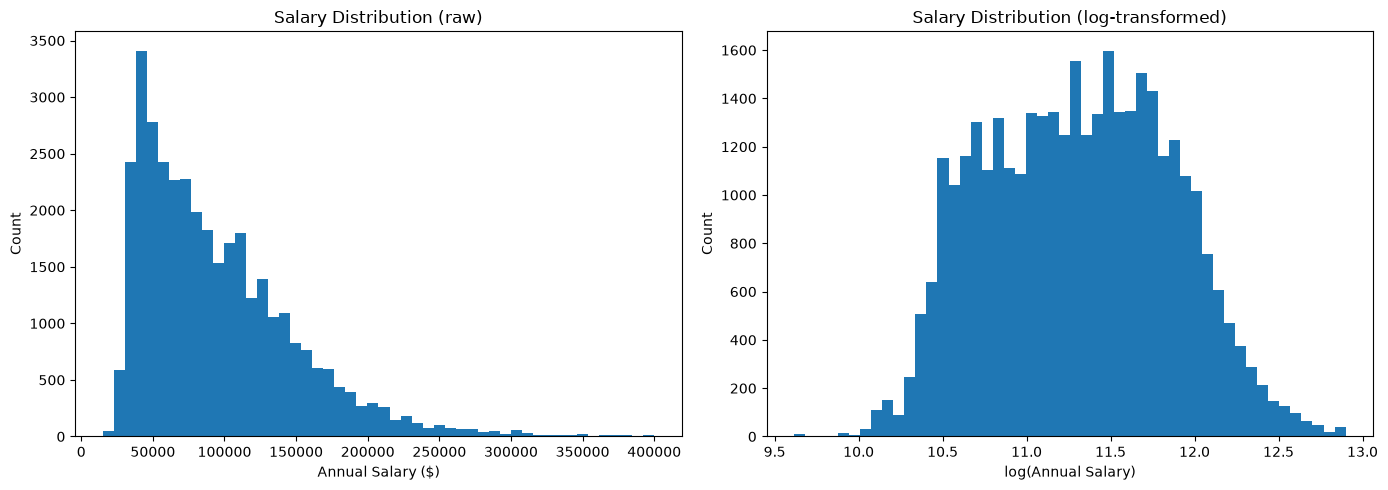

Skewness (raw): 1.3502614532461734
Skewness (log): 0.06040753130628772


In [224]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: normal salary numbers
axes[0].hist(df_clean['normalized_salary'], bins=50)
axes[0].set_title('Salary Distribution (raw)')
axes[0].set_xlabel('Annual Salary ($)')
axes[0].set_ylabel('Count')

# Chart 2: same data, but "squished" using log so it's easier to see the shape
axes[1].hist(np.log1p(df_clean['normalized_salary']), bins=50)
axes[1].set_title('Salary Distribution (log-transformed)')
axes[1].set_xlabel('log(Annual Salary)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('summative/linear_regression/salary_distribution.png', dpi=100)
plt.show()

print("Skewness (raw):", df_clean['normalized_salary'].skew())
print("Skewness (log):", np.log1p(df_clean['normalized_salary']).skew())

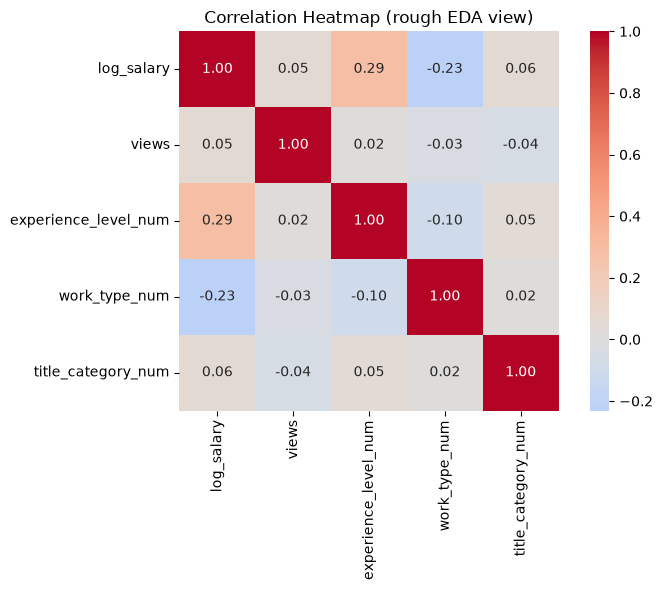

log_salary              1.00
experience_level_num    0.29
title_category_num      0.06
views                   0.05
work_type_num          -0.23
Name: log_salary, dtype: float64


In [225]:
df_corr = df_clean.copy()

experience_order = {
    'Not Specified': 0, 'Internship': 1, 'Entry level': 2,
    'Associate': 3, 'Mid-Senior level': 4, 'Director': 5, 'Executive': 6
}
df_corr['experience_level_num'] = df_corr['formatted_experience_level'].map(experience_order)

df_corr['work_type_num'] = df_corr['formatted_work_type'].astype('category').cat.codes
df_corr['title_category_num'] = df_corr['title_category'].astype('category').cat.codes

df_corr['log_salary'] = np.log1p(df_corr['normalized_salary'])

corr_cols = ['log_salary', 'views', 'experience_level_num', 'work_type_num', 'title_category_num']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap (rough EDA view)')
plt.tight_layout()
plt.savefig('summative/linear_regression/correlation_heatmap.png', dpi=100)
plt.show()

print(corr_matrix['log_salary'].sort_values(ascending=False))

In [226]:
print("Unique locations:", df_clean['location'].nunique())
print()
print(df_clean['location'].value_counts().head(20))

Unique locations: 4490

location
United States                      2541
New York, NY                       1489
Los Angeles, CA                     523
Chicago, IL                         456
New York City Metropolitan Area     447
Seattle, WA                         430
Denver, CO                          404
San Francisco, CA                   397
San Diego, CA                       382
Houston, TX                         341
Atlanta, GA                         334
Boston, MA                          323
Washington, DC                      297
Phoenix, AZ                         293
Dallas, TX                          289
Austin, TX                          277
New York, United States             261
Charlotte, NC                       240
San Jose, CA                        229
Sacramento, CA                      210
Name: count, dtype: int64


In [227]:
import re


def extract_state(location):
    loc = str(location).strip()
    match = re.search(r',\s*([A-Z]{2})$', loc)
    if match:
        return match.group(1)
    elif loc == 'United States':
        return 'US - Unspecified'
    elif 'Metropolitan Area' in loc or 'Area' in loc:
        return 'US - Metro Area (Unspecified State)'
    else:
        return 'International/Other'

df_clean['state'] = df_clean['location'].apply(extract_state)

print("Unique states/categories:", df_clean['state'].nunique())
print()
print(df_clean['state'].value_counts().head(20))
print()
other_pct = (df_clean['state'] == 'International/Other').mean() * 100
print(f"'International/Other': {other_pct:.1f}%")



Unique states/categories: 54

state
CA                                     5695
NY                                     2960
US - Unspecified                       2541
TX                                     1938
International/Other                    1828
US - Metro Area (Unspecified State)    1732
FL                                     1375
WA                                     1346
CO                                     1143
IL                                     1063
NJ                                      870
MA                                      865
PA                                      852
NC                                      827
VA                                      793
GA                                      759
OH                                      712
AZ                                      657
MI                                      533
MD                                      528
Name: count, dtype: int64

'International/Other': 5.2%


In [228]:
df_clean = df_clean.drop(columns=['location'])
df_clean.head()

,job_id,views,formatted_work_type,formatted_experience_level,normalized_salary,title_category,state
0,921716,20.00,Full-time,Not Specified,"38,480.00",Marketing,NJ
1,1829192,1.00,Full-time,Not Specified,"83,200.00",Healthcare,CO
2,10998357,8.00,Full-time,Not Specified,"55,000.00",Management/Executive,OH
3,23221523,16.00,Full-time,Not Specified,"157,500.00",Senior/Lead,NY
4,35982263,3.00,Full-time,Not Specified,"70,000.00",Technical/Trades,IA


In [229]:
experience_order = {
    'Not Specified': 0, 'Internship': 1, 'Entry level': 2,
    'Associate': 3, 'Mid-Senior level': 4, 'Director': 5, 'Executive': 6
}
df_model = df_clean.copy()
df_model['experience_level_encoded'] = df_model['formatted_experience_level'].map(experience_order)

df_model = pd.get_dummies(
    df_model,
    columns=['title_category', 'state', 'formatted_work_type'],
    drop_first=True  
)


df_model['log_salary'] = np.log1p(df_model['normalized_salary'])

drop_cols = ['job_id', 'formatted_experience_level', 'normalized_salary']
df_model = df_model.drop(columns=drop_cols)

print("Final feature matrix shape:", df_model.shape)
print()
print(df_model.columns.tolist())


Final feature matrix shape: (35449, 78)

['views', 'experience_level_encoded', 'title_category_Customer Service/Support', 'title_category_Data/Analytics', 'title_category_Design', 'title_category_Education', 'title_category_Engineering', 'title_category_Finance', 'title_category_General Labor/Hospitality', 'title_category_HR/Recruiting', 'title_category_Healthcare', 'title_category_Legal', 'title_category_Management/Executive', 'title_category_Marketing', 'title_category_Other', 'title_category_Sales', 'title_category_Senior/Lead', 'title_category_Technical/Trades', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_International/Other', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 's

In [230]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) from target (y)
X = df_model.drop(columns=['log_salary'])
y = df_model['log_salary']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Scale only the numeric (non one-hot) columns — one-hot columns are already 0/1,
# scaling them would distort that meaning
numeric_cols = ['views', 'experience_level_encoded']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY on training data
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# Apply (not re-fit) to test data
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print()
print("Scaled training numeric columns preview:")
X_train_scaled[numeric_cols].describe()

X_train shape: (28359, 77)
X_test shape: (7090, 77)

Scaled training numeric columns preview:


,views,experience_level_encoded
count,"28,359.00","28,359.00"
mean,-0.00,0.00
std,1.00,1.00
min,-0.15,-1.54
25%,-0.13,-0.31
50%,-0.11,0.30
75%,-0.07,0.91
max,75.79,2.14


In [231]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

models = {
    'SGDRegressor (stochastic)': SGDRegressor(max_iter=1000, random_state=42),
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=10, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    results[name] = {
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'train_r2': r2_score(y_train, train_pred),
        'test_r2': r2_score(y_test, test_pred),
    }
    print(f"{name}: done")

results_df = pd.DataFrame(results).T
results_df

SGDRegressor (stochastic): done
LinearRegression: done
RandomForestRegressor: done
DecisionTreeRegressor: done


,train_rmse,test_rmse,train_r2,test_r2
SGDRegressor (stochastic),0.44,0.44,0.36,0.35
LinearRegression,0.43,0.44,0.38,0.36
RandomForestRegressor,0.29,0.44,0.73,0.36
DecisionTreeRegressor,0.41,0.43,0.44,0.40


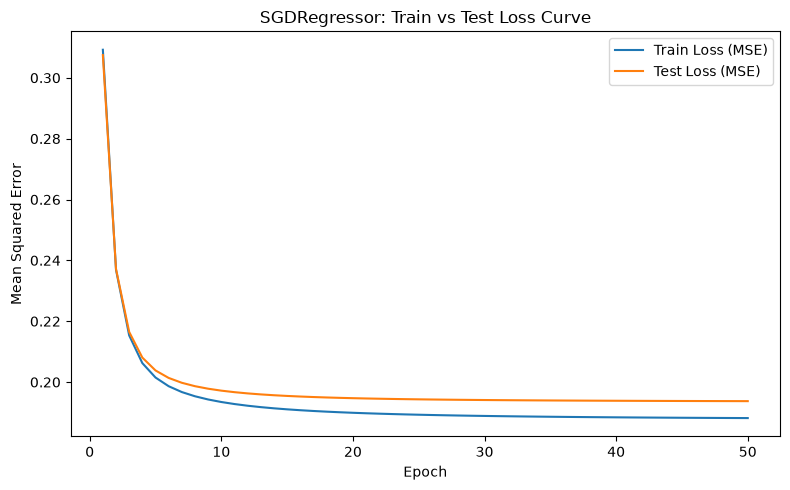

Final train loss: 0.1882
Final test loss: 0.1937


In [232]:
n_epochs = 50
sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42, learning_rate='invscaling', eta0=0.01)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_pred = sgd.predict(X_train_scaled)
    test_pred = sgd.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss (MSE)')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('SGDRegressor: Train vs Test Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('summative/linear_regression/loss_curve.png', dpi=100)
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")

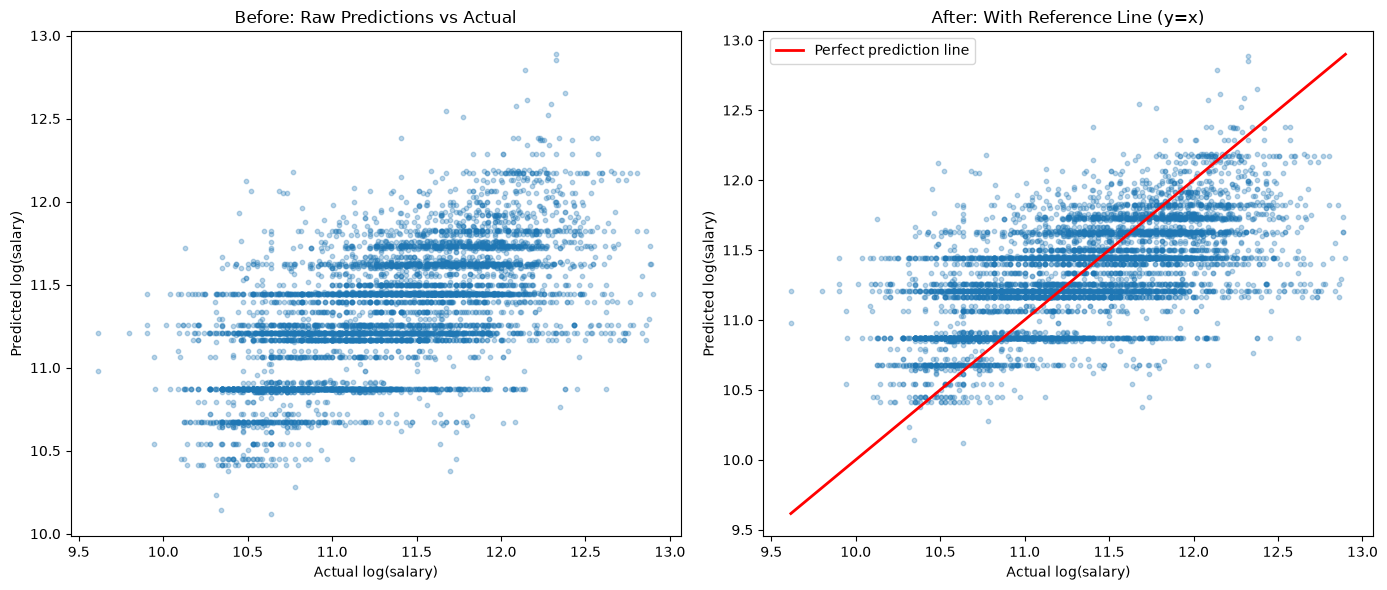

In [233]:
# finding the best Model
best_model = models['DecisionTreeRegressor']
test_pred = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# "Before" — raw scatter of actual vs predicted, no reference line
axes[0].scatter(y_test, test_pred, alpha=0.3, s=10)
axes[0].set_xlabel('Actual log(salary)')
axes[0].set_ylabel('Predicted log(salary)')
axes[0].set_title('Before: Raw Predictions vs Actual')

# "After" — same scatter, with the perfect-prediction line overlaid
axes[1].scatter(y_test, test_pred, alpha=0.3, s=10)
min_val, max_val = y_test.min(), y_test.max()
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect prediction line')
axes[1].set_xlabel('Actual log(salary)')
axes[1].set_ylabel('Predicted log(salary)')
axes[1].set_title('After: With Reference Line (y=x)')
axes[1].legend()

plt.tight_layout()
plt.savefig('summative/linear_regression/scatter_fit_line.png', dpi=100)
plt.show()

In [234]:
import joblib

joblib.dump(best_model, 'summative/linear_regression/best_model.joblib')
joblib.dump(scaler, 'summative/linear_regression/scaler.joblib')

joblib.dump(X_train.columns.tolist(), 'summative/linear_regression/model_columns.joblib')

print("Saved: best_model.joblib, scaler.joblib, model_columns.joblib")

Saved: best_model.joblib, scaler.joblib, model_columns.joblib


In [237]:
import joblib
import numpy as np

# Load everything 
loaded_model = joblib.load('summative/linear_regression/best_model.joblib')
loaded_scaler = joblib.load('summative/linear_regression/scaler.joblib')
loaded_columns = joblib.load('summative/linear_regression/model_columns.joblib')

# Take one row from the test set as a stand-in for "a new prediction request"
sample_row = X_test.iloc[[0]].copy()

# Scale the numeric columns the same way training data was scaled
numeric_cols = ['views', 'experience_level_encoded']
sample_row[numeric_cols] = loaded_scaler.transform(sample_row[numeric_cols])

# Ensure column order matches exactly what the model was trained on
sample_row = sample_row[loaded_columns]

prediction_log = loaded_model.predict(sample_row)[0]
prediction_salary = np.expm1(prediction_log)  

actual_log = y_test.iloc[0]
actual_salary = np.expm1(actual_log)

print(f"Predicted salary: ${prediction_salary:,.2f}")
print(f"Actual salary:    ${actual_salary:,.2f}")
print(f"Difference:       ${abs(prediction_salary - actual_salary):,.2f}")

Predicted salary: $83,642.70
Actual salary:    $182,500.00
Difference:       $98,857.30


In [ ]:
# Check predictions across several rows, not just one, for it to make more sense
sample_rows = X_test.iloc[:10].copy()
sample_rows[numeric_cols] = loaded_scaler.transform(sample_rows[numeric_cols])
sample_rows = sample_rows[loaded_columns]

preds_log = loaded_model.predict(sample_rows)
preds_salary = np.expm1(preds_log)
actual_salary_10 = np.expm1(y_test.iloc[:10].values)

comparison = pd.DataFrame({
    'actual': actual_salary_10,
    'predicted': preds_salary,
    'diff': np.abs(actual_salary_10 - preds_salary)
})
comparison['pct_error'] = (comparison['diff'] / comparison['actual'] * 100).round(1)
print(comparison.round(2))
print()
print(f"Mean % error across these 10 rows: {comparison['pct_error'].mean():.1f}%")

      actual  predicted      diff  pct_error
0 182,500.00  83,642.70 98,857.30      54.20
1  83,750.00  98,545.16 14,795.16      17.70
2  62,400.00  70,536.24  8,136.24      13.00
3 114,400.00  93,307.76 21,092.24      18.40
4  87,500.00 104,200.61 16,700.61      19.10
5  85,000.00 126,843.51 41,843.51      49.20
6  90,000.00 124,222.69 34,222.69      38.00
7  46,696.00  52,688.76  5,992.76      12.80
8  52,000.00  93,307.76 41,307.76      79.40
9  39,520.00  77,621.24 38,101.24      96.40

Mean % error across these 10 rows: 39.8%


In [239]:
print("Work types:", df_clean['formatted_work_type'].unique().tolist())
print()
print("Experience levels:", df_clean['formatted_experience_level'].unique().tolist())

Work types: ['Full-time', 'Internship', 'Contract', 'Part-time', 'Temporary', 'Other', 'Volunteer']

Experience levels: ['Not Specified', 'Mid-Senior level', 'Associate', 'Entry level', 'Director', 'Internship', 'Executive']


In [240]:
print("Title categories (all):")
print(sorted(df_clean['title_category'].unique().tolist()))
print()
print("States (all):")
print(sorted(df_clean['state'].unique().tolist()))

Title categories (all):
['Administrative/Office Support', 'Customer Service/Support', 'Data/Analytics', 'Design', 'Education', 'Engineering', 'Finance', 'General Labor/Hospitality', 'HR/Recruiting', 'Healthcare', 'Legal', 'Management/Executive', 'Marketing', 'Other', 'Sales', 'Senior/Lead', 'Technical/Trades']

States (all):
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'International/Other', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'US - Metro Area (Unspecified State)', 'US - Unspecified', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


In [ ]:
df_clean.to_csv('summative/linear_regression/cleaned_base_data.csv', index=False)
print("Saved cleaned_base_data.csv, shape:", df_clean.shape)